<a href="https://colab.research.google.com/github/gimoonnam/vgg16_practice/blob/main/notebooks/train_on_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Modules

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path(os.getcwd()).resolve()))

from tqdm import tqdm
from torchsummary import summary

import torch
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

import wandb
from torchsummary import summary

### Mount to Google drive

In [2]:
from google.colab import drive, userdata

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully!")
else:
    print("Drive already mounted.")

Mounted at /content/drive
Drive mounted successfully!


### Clone git and load modules

In [3]:
!git clone https://github.com/gimoonnam/vgg16_practice.git

Cloning into 'vgg16_practice'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 174 (delta 84), reused 88 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 1.27 MiB | 22.82 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [4]:
repo_path = '/content/vgg16_practice'
if repo_path not in sys.path:
  sys.path.insert(0, repo_path)

from src.load_data import split_dataset
from models.vgg16 import VGG16
from src.data_classes import TrainingConfig

In [5]:
data_path = r'/content/drive/My Drive/Data for Colab Training'

# CIFAR10 dataset
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")

Training samples: 50000
Test samples: 10000


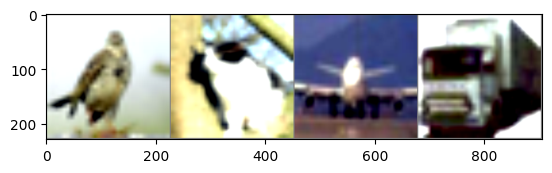

bird  cat   plane truck


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

NUM_CLASSES = len(classes)

# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


In [7]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Configuration for training
config = TrainingConfig(
    batch_size=128,
    num_epochs=10,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=10,
    learning_rate=1e-3,
    weight_decay=1e-4,
    save_path=r"/Users/gimoon/Documents/GitHub/vgg16_practice/checkpoints"
)
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training set size: 40000
Validation set size: 10000

Train batches: 313
Validation batches: 79


### Load VGG16 model

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torchvision import models

# load pretrained VGG16 model from torchvision, where weights='default' uses pretrained weights on ImageNet1K_V1
model = models.vgg16(weights='DEFAULT')

# freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last layer of the classifier
model.classifier[3].requires_grad_ = True

# customize the last layer of the classifier to match the number of classes
model.classifier[6] = nn.Sequential(
                      nn.Linear(4096, 512),
                      nn.ReLU(),
                      nn.Dropout(0.5),
                      nn.Linear(512, NUM_CLASSES))

model = model.to(device)
model.classifier

summary(model, (3, 224, 224))


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 189MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [9]:
device

device(type='cuda')

In [10]:
# lr_scheduler_step_size = config.lr_scheduler_step_size()
# print(lr_scheduler_step_size)

# total_steps = config.total_steps()
# print(total_steps)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
# scheduler = StepLR(optimizer, step_size=config.lr_scheduler_epoch, gamma=0.5)

In [11]:
import numpy as np

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [12]:
from datetime import datetime
import pytz

asia_tz = pytz.timezone("Asia/Seoul")
saved_time = datetime.now(asia_tz).strftime("%Y-%m-%d %H:%M:%S")
run_name = f"checkpoint_CIFAR10_batchSize{config.batch_size}_nEpoch{config.num_epochs}_lr{config.learning_rate}_AdamW_weightDecay1e-4_{saved_time}"
print(run_name)

checkpoint_CIFAR10_batchSize128_nEpoch10_lr0.001_AdamW_weightDecay1e-4_2026-02-21 15:34:04


### Configuring WandB

In [13]:
os.environ["WANDB_API_KEY"] = userdata.get('wandb_key')
wandb.login()

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="gimoonnam",
    # Set the wandb project where this run will be logged.
    project="vgg16_practice",
    # Track hyperparameters and,
    name = run_name,

    config={
        "learning_rate": config.learning_rate,
        "architecture": "CNN",
        "dataset": "CIFAR-10",
        "epochs": config.num_epochs,
    },
)




/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gimoonnam to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Training along with validating

In [14]:
# curr_lr = scheduler.get_last_lr()[0]
# early_stopping = EarlyStopping(patience=5, verbose=True)


def compute_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in data_loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def compute_epoch_loss(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    num_examples = 0
    for features, labels in data_loader:
        features, labels = features.to(device), labels.to(device)
        logits = model(features)
        loss = criterion(logits, labels)
        epoch_loss += loss.item()
        num_examples += features.size(0)
    return epoch_loss / num_examples



for epoch in range(config.num_epochs):
    # ==================== TRAINING ====================
    model.train()
    epoch_train_loss = 0.0

    ProgressBar = tqdm(enumerate(train_loader), total=len(train_loader))

    for batch_idx, (inputs, labels) in ProgressBar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Update Progress bar (only training loss during training)
        ProgressBar.set_description(f'Epoch [{epoch+1}/{config.num_epochs}]')
        ProgressBar.set_postfix(TrainLoss=loss.item())

    # Average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)

    # ==================== VALIDATION (Once per epoch) ====================
    print(f"\nRunning validation for epoch {epoch+1}...")
    with torch.no_grad():
        avg_val_acc = compute_accuracy(model, val_loader, device)
        avg_val_loss = compute_epoch_loss(model, val_loader, criterion, device)

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {avg_val_acc:.4f}")

    # Update learning rate scheduler
    # scheduler.step()
    # curr_lr = scheduler.get_last_lr()[0]


    # Log metrics to wandb (once per epoch)
    run.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_accuracy": avg_val_acc,
        #"lr": curr_lr
    })

    # Check early stopping
    # early_stopping(avg_val_loss, model)
    # if early_stopping.early_stop:
    #     print("Early stopping triggered. Training halted.")
    #     break


run.finish()


# TODO:
# 1. clean this cell by using calc_accuracy_loader(..) and evaluate_model()


Epoch [1/10]: 100%|██████████| 313/313 [04:29<00:00,  1.16it/s, TrainLoss=0.82]



Running validation for epoch 1...

Epoch 1 Summary:
  Train Loss: 0.7157
  Val Loss:   0.0042
  Val Acc:    0.8120


Epoch [2/10]: 100%|██████████| 313/313 [04:31<00:00,  1.15it/s, TrainLoss=0.65]



Running validation for epoch 2...

Epoch 2 Summary:
  Train Loss: 0.6091
  Val Loss:   0.0038
  Val Acc:    0.8280


Epoch [3/10]: 100%|██████████| 313/313 [04:32<00:00,  1.15it/s, TrainLoss=0.539]


...

Epoch [9/10]: 100%|██████████| 313/313 [04:31<00:00,  1.15it/s, TrainLoss=0.621]



Running validation for epoch 9...

Epoch 9 Summary:
  Train Loss: 0.5191
  Val Loss:   0.0035
  Val Acc:    0.8432


Epoch [10/10]: 100%|██████████| 313/313 [04:32<00:00,  1.15it/s, TrainLoss=0.612]



Running validation for epoch 10...

Epoch 10 Summary:
  Train Loss: 0.5230
  Val Loss:   0.0035
  Val Acc:    0.8430


train_loss,█▄▃▃▂▂▂▁▁▁
val_accuracy,▁▄▅▆▆▇▇███
val_loss,█▅▄▃▂▂▂▁▁▁
train_loss,0.52303
val_accuracy,0.843
val_loss,0.00346


In [15]:
# from models.vgg16 import save_checkpoint, load_checkpoint

checkpoint_path = r'/content/drive/My Drive/checkpoints'

checkpoint = {
    "batch_size": config.batch_size,
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}

save_pth = os.path.join(checkpoint_path, f"{run_name}.pth.tar")
print(save_pth)
torch.save(checkpoint, save_pth)

# pth_file_path = os.path.join(checkpoint_path, 'checkpoint-2026-02-12 09_10_08.pth')
# model, optimizer, epoch, loss = load_checkpoint(pth_file_path, model, optimizer)

/content/drive/My Drive/checkpoints/checkpoint_CIFAR10_batchSize128_nEpoch10_lr0.001_AdamW_weightDecay1e-4_2026-02-21 15:34:04.pth.tar


In [16]:
@torch.no_grad()  # Disable gradient tracking for efficiency
def calc_accuracy_loader(data_loader, model, device, num_batches=None, desc='testing'):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(tqdm(data_loader, desc)):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            logits = model(input_batch)
            predicted_labels = torch.argmax(logits, dim=1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [17]:
test_loader = DataLoader(dataset_test, batch_size=config.batch_size, shuffle=False)

calc_accuracy_loader(test_loader, model, device, config.batch_size )

testing: 100%|██████████| 79/79 [01:07<00:00,  1.16it/s]


0.8372